# Module 10: Image & Signal Preprocessing for AI
## HealthAI 360: Dermatology Vision & Digital Stethoscope Acoustic Intelligence
**Curriculum Track:** Module 10 (Vision & Biosignals)  
**Persona:** Professor CodeBreaker  
**Goal:** Prepare unstructured high-dimensional medical imaging and continuous acoustic biosignals for computer vision and machine learning classifiers.

---
### What You Will Learn:
1. **Dermatology Image Preprocessing:** CLAHE (Contrast Limited Adaptive Histogram Equalization), letterboxing/aspect-ratio preservation, data augmentation (rotations, flips, color jitter), and handling class imbalance.
2. **Curse of Dimensionality Reduction:** Applying PCA to retain 95% variance while shrinking feature space by over 90%.
3. **Digital Stethoscope Acoustic Preprocessing:** Sampling rates ($f_s$), Nyquist frequency ($f_{Nyquist} = f_s / 2$), and zero-phase Butterworth bandpass filtering (25 Hz - 450 Hz) for heart sounds.
4. **Time-Frequency Representation:** Short-Time Fourier Transform (STFT) and Log-Power Spectrograms for murmur detection.

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.image_pipeline.loading import load_images_from_dirs
from src.image_pipeline.normalization import apply_clahe, normalize_batch
from src.image_pipeline.signal_processor import BiosignalPreprocessor, run_signal_pipeline
from src.image_pipeline.pipeline import run_image_pipeline

print("[Setup] Module 10 vision & biosignal libraries successfully imported!")

[Setup] Module 10 vision & biosignal libraries successfully imported!


## Part A: Dermatology Skin Lesion Preprocessing
In dermoscopic imaging, low contrast, varying illumination, and subtle border variations make direct raw pixel classification ineffective.  
Let's inspect raw images and compare them with **CLAHE local contrast enhancement**.

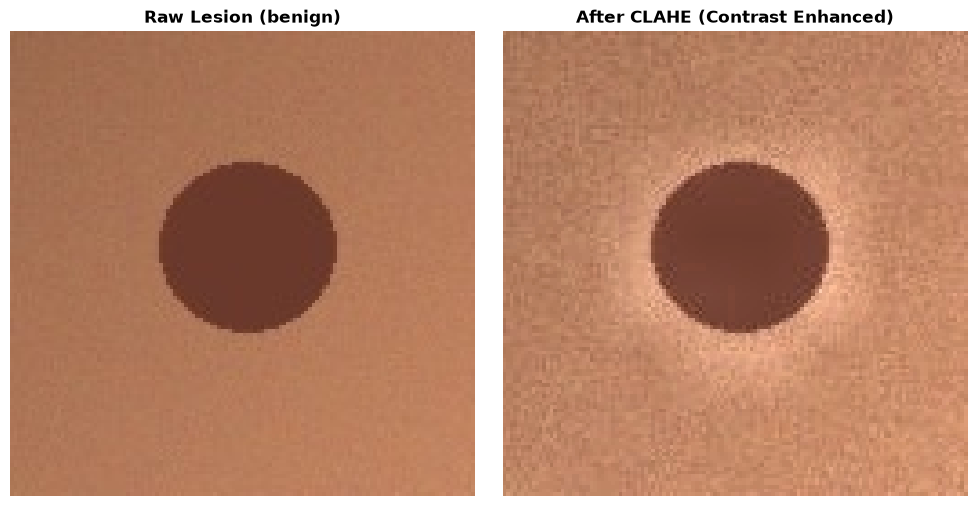

In [2]:
img_dir = REPO_ROOT / "data" / "image" / "raw"
images, labels, paths = load_images_from_dirs(str(img_dir))

# Pick a sample image
sample_img = images[10]
sample_clahe = apply_clahe(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_img)
axes[0].set_title(f"Raw Lesion ({labels[10]})", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(sample_clahe)
axes[1].set_title("After CLAHE (Contrast Enhanced)", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Image Pipeline Execution: PCA & Class Weighting
Raw $224 \times 224 \times 3$ images contain over 150,000 dimensions per sample.  
Let's execute the full vision pipeline to benchmark raw pixels against CLAHE + PCA dimensionality reduction:

In [3]:
img_results = run_image_pipeline(str(img_dir))


  [MODULE 10] Running Dermatology Image Preprocessing Pipeline


  Loaded 600 lesion images across 3 classes: [np.str_('benign'), np.str_('inflammatory'), np.str_('malignant')]


  Applying CLAHE local contrast enhancement and channel normalization...


  Fitting Randomized PCA (50 principal components)...


  Dimensionality reduced: 49,152 pixels -> 50 PCA components (96.3% variance retained)
  [RESULT] Image Baseline (Raw Pixels) -> Accuracy: 0.9667 | F1-Macro: 0.9666
  [RESULT] Image Processed (CLAHE+PCA) -> Accuracy: 0.9333 | F1-Macro: 0.9330 (Delta: +-0.0336)


## Part B: Biosignal & Acoustic Processing (Digital Stethoscope PCG)
Phonocardiogram (PCG) acoustic recordings capture heart sounds:
- **S1 (lub):** Closure of mitral and tricuspid valves (~100-150 Hz).
- **S2 (dub):** Closure of aortic and pulmonary valves (~150-200 Hz).
- **Murmurs:** High-frequency turbulent blood flow (200-450 Hz).
- **Artifacts:** Patient movement, breathing, ambient stethoscope friction (<20 Hz and >500 Hz).

### The Nyquist Criterion:
To prevent aliasing, the sampling rate must satisfy:
$$f_s \ge 2 \cdot f_{max}$$
Here $f_s = 2000$ Hz, meaning $f_{Nyquist} = 1000$ Hz, which easily accommodates the 450 Hz cardiac acoustic band.

In [4]:
sig_dir = REPO_ROOT / "data" / "signal"
signals = np.load(sig_dir / "pcg_signals.npy")
labels_sig = np.load(sig_dir / "pcg_labels.npy")
with open(sig_dir / "signal_meta.json") as f:
    sig_meta = json.load(f)

fs = sig_meta["sampling_rate"]
duration = sig_meta["duration_sec"]
t = np.linspace(0, duration, len(signals[0]))

print(f"Loaded {len(signals)} PCG signals | fs={fs}Hz | Duration={duration}s")

Loaded 120 PCG signals | fs=2000Hz | Duration=2.0s


### Visualizing Butterworth Filtering & STFT Spectrograms
Let's filter out baseline drift and high-frequency friction using a 4th-order zero-phase Butterworth bandpass filter (25-450 Hz), then compute the STFT spectrogram:

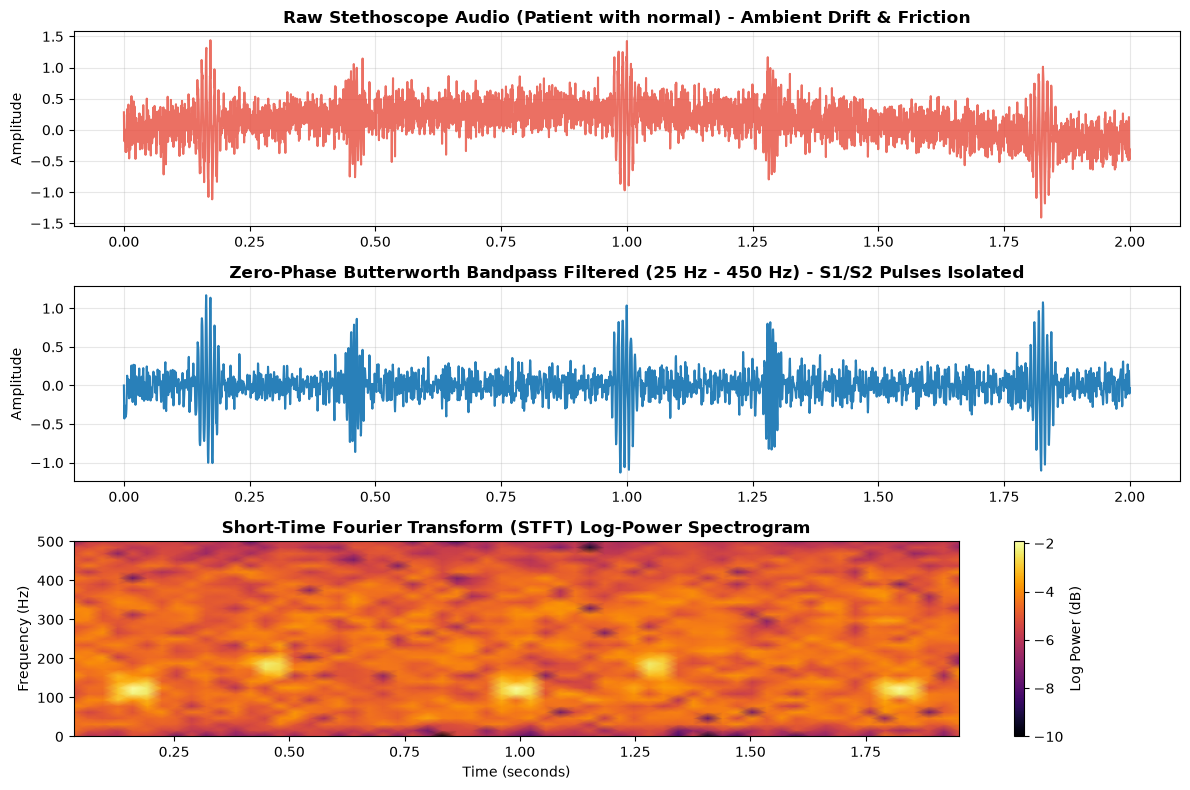

In [5]:
preproc = BiosignalPreprocessor(fs=fs, lowcut=25.0, highcut=450.0)

idx = 0  # Sample signal
raw_sig = signals[idx]
filtered_sig = preproc.bandpass_filter(raw_sig)
f, time_bins, Sxx_log = preproc.compute_spectrogram(filtered_sig)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

# 1. Raw Waveform
axes[0].plot(t, raw_sig, color="#e74c3c", alpha=0.8)
axes[0].set_title(f"Raw Stethoscope Audio (Patient with {labels_sig[idx]}) - Ambient Drift & Friction", fontweight="bold")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# 2. Filtered Waveform
axes[1].plot(t, filtered_sig, color="#2980b9")
axes[1].set_title("Zero-Phase Butterworth Bandpass Filtered (25 Hz - 450 Hz) - S1/S2 Pulses Isolated", fontweight="bold")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

# 3. STFT Spectrogram
im = axes[2].pcolormesh(time_bins, f, Sxx_log, shading="gouraud", cmap="inferno")
axes[2].set_title("Short-Time Fourier Transform (STFT) Log-Power Spectrogram", fontweight="bold")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylim(0, 500)
fig.colorbar(im, ax=axes[2], label="Log Power (dB)")

plt.tight_layout()
plt.show()

### Biosignal Pipeline Benchmark: Murmur Detection

In [6]:
sig_results = run_signal_pipeline(str(sig_dir))

  [RESULT] Signal Baseline   -> Accuracy: 0.5333 | F1-Macro: 0.5312
  [RESULT] Signal Processed  -> Accuracy: 0.8667 | F1-Macro: 0.8643 (Delta: +0.3330)
